In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 150,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False
})

RESULTS_DIR = Path('../results')
TABLES_DIR = RESULTS_DIR / 'tables'
FIGURES_DIR = RESULTS_DIR / 'figures'

COLORS = {
    'rf': '#2E86AB',       
    'lgb': '#E94F37',      
    'lr': '#7B8D8E',       
    'dt': '#A8DADC'       
}

In [ ]:
# Load all results
rf_results = pd.read_csv(TABLES_DIR / 'rf_complexity_results.csv')
lgb_results = pd.read_csv(TABLES_DIR / 'lgb_complexity_results.csv')
summary = pd.read_csv(TABLES_DIR / 'complexity_summary.csv')
all_results = pd.read_csv(TABLES_DIR / 'all_profiling_results.csv')

print("Random Forest configurations:")
display(rf_results)
print("\nLightGBM configurations:")
display(lgb_results)
print("\nSummary:")
display(summary)

Random Forest configurations:


,n_estimators,max_depth,train_time_ms,infer_time_ms,memory_mb,accuracy
0,10,5,349.274449,2.661180,0.059929,1.0
1,50,5,1449.341217,9.642328,0.080118,1.0
2,100,5,2182.770785,18.897243,0.111956,1.0
3,100,10,2137.645587,19.521767,0.112567,1.0
4,100,15,2166.240631,17.801839,0.110231,1.0
5,200,10,4149.908192,36.718574,0.182251,1.0



LightGBM configurations:


,n_estimators,max_depth,num_leaves,train_time_ms,infer_time_ms,memory_mb,accuracy
0,10,5,31,220.516278,2.886786,1.095819,0.961538
1,50,5,31,120.531959,2.972305,1.059655,0.961538
2,100,5,31,37.426597,3.404026,1.105595,0.961538
3,100,10,64,44.901283,3.678712,1.094934,0.961538
4,100,15,128,45.969976,9.107634,1.100242,0.961538
5,200,10,64,880.655359,6.131589,1.100793,0.961538



Summary:


,Model,Training Time (ms),Inference Time (ms),Memory (MB),Accuracy,Theoretical Training
0,Logistic Regression,229.174519,0.294234,0.048315,1.000000,O(n·d·i)
1,Decision Tree,26.765036,0.603445,0.028455,0.961538,O(n·d·log(n))
2,"Random Forest (k=10, h=5)",349.274449,2.661180,0.059929,1.000000,O(k·n·d·log(n))
3,"LightGBM (k=10, h=5)",220.516278,2.886786,1.095819,0.961538,O(n·d·k)


## Figure 1: Training Time Scaling

Demonstrates how training complexity grows with ensemble size (k) for both algorithms.


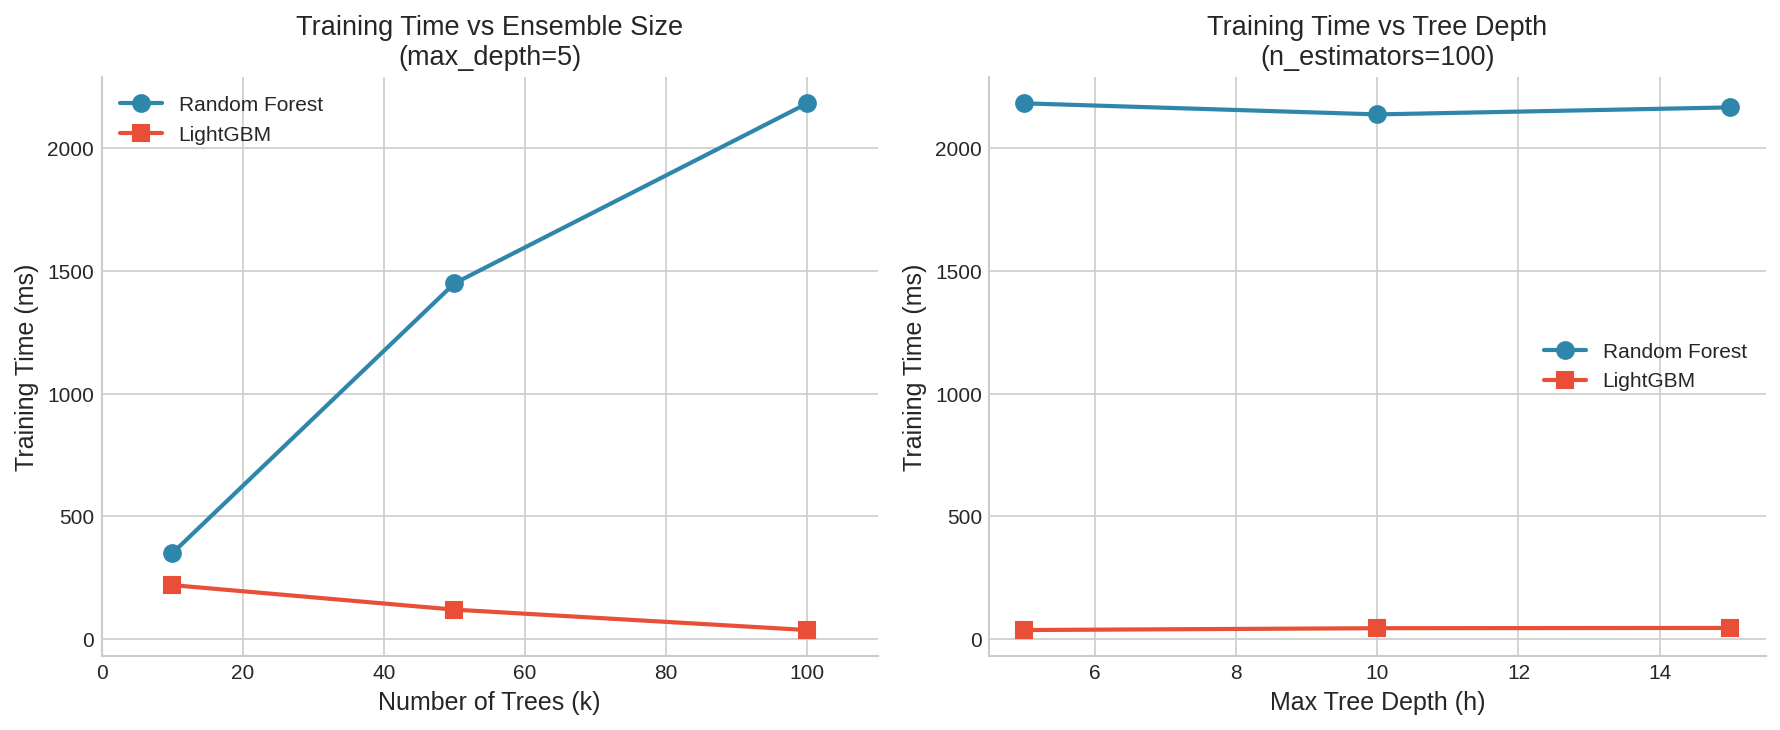

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Training time vs number of trees (fixed depth=5)
rf_d5 = rf_results[rf_results['max_depth'] == 5].sort_values('n_estimators')
lgb_d5 = lgb_results[lgb_results['max_depth'] == 5].sort_values('n_estimators')

ax1 = axes[0]
ax1.plot(rf_d5['n_estimators'], rf_d5['train_time_ms'], 'o-', 
         color=COLORS['rf'], linewidth=2, markersize=8, label='Random Forest')
ax1.plot(lgb_d5['n_estimators'], lgb_d5['train_time_ms'], 's-', 
         color=COLORS['lgb'], linewidth=2, markersize=8, label='LightGBM')

ax1.set_xlabel('Number of Trees (k)')
ax1.set_ylabel('Training Time (ms)')
ax1.set_title('Training Time vs Ensemble Size\n(max_depth=5)')
ax1.legend()
ax1.set_xlim(0, 110)

# Right: Training time vs max depth (fixed k=100)
rf_k100 = rf_results[rf_results['n_estimators'] == 100].sort_values('max_depth')
lgb_k100 = lgb_results[lgb_results['n_estimators'] == 100].sort_values('max_depth')

ax2 = axes[1]
ax2.plot(rf_k100['max_depth'], rf_k100['train_time_ms'], 'o-', 
         color=COLORS['rf'], linewidth=2, markersize=8, label='Random Forest')
ax2.plot(lgb_k100['max_depth'], lgb_k100['train_time_ms'], 's-', 
         color=COLORS['lgb'], linewidth=2, markersize=8, label='LightGBM')

ax2.set_xlabel('Max Tree Depth (h)')
ax2.set_ylabel('Training Time (ms)')
ax2.set_title('Training Time vs Tree Depth\n(n_estimators=100)')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_training_time_scaling.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'fig1_training_time_scaling.pdf', bbox_inches='tight')
plt.show()

##  Figure 2: Inference Latency Analysis

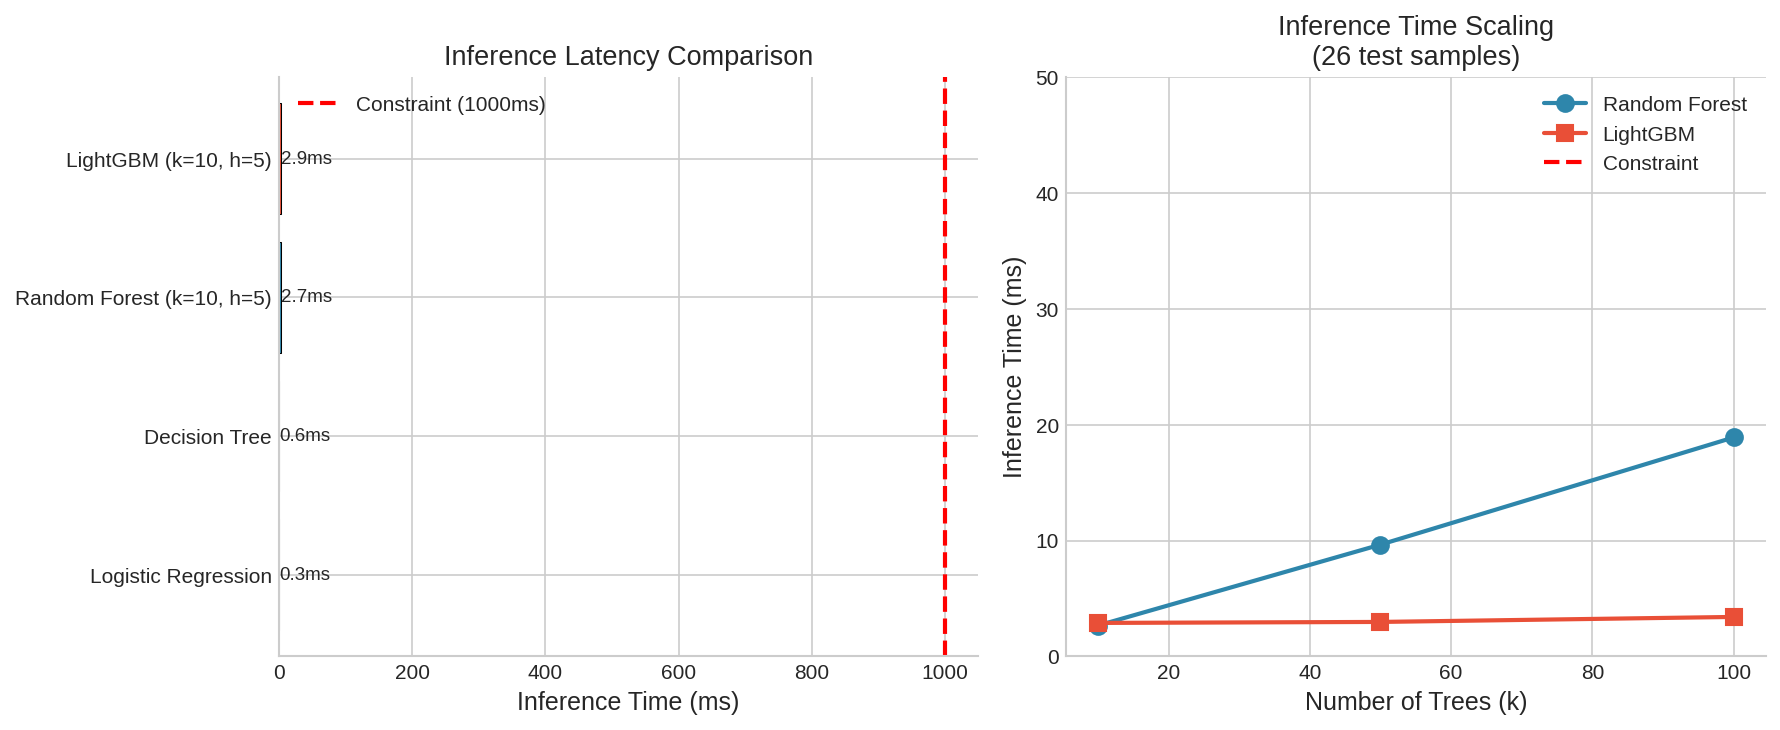

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

summary_sorted = summary.sort_values('Inference Time (ms)')
colors = [COLORS['lr'] if 'Logistic' in m else COLORS['dt'] if 'Decision' in m 
          else COLORS['rf'] if 'Random' in m else COLORS['lgb'] 
          for m in summary_sorted['Model']]

ax1 = axes[0]
bars = ax1.barh(summary_sorted['Model'], summary_sorted['Inference Time (ms)'], 
                color=colors, edgecolor='black', linewidth=0.5)
ax1.axvline(x=1000, color='red', linestyle='--', linewidth=2, label='Constraint (1000ms)')
ax1.set_xlabel('Inference Time (ms)')
ax1.set_title('Inference Latency Comparison')
ax1.legend()

for bar, val in zip(bars, summary_sorted['Inference Time (ms)']):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}ms', va='center', fontsize=9)

ax2 = axes[1]
ax2.plot(rf_d5['n_estimators'], rf_d5['infer_time_ms'], 'o-', 
         color=COLORS['rf'], linewidth=2, markersize=8, label='Random Forest')
ax2.plot(lgb_d5['n_estimators'], lgb_d5['infer_time_ms'], 's-', 
         color=COLORS['lgb'], linewidth=2, markersize=8, label='LightGBM')

ax2.axhline(y=1000, color='red', linestyle='--', linewidth=2, label='Constraint')
ax2.set_xlabel('Number of Trees (k)')
ax2.set_ylabel('Inference Time (ms)')
ax2.set_title('Inference Time Scaling\n(26 test samples)')
ax2.legend()
ax2.set_ylim(0, 50)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_inference_latency.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'fig2_inference_latency.pdf', bbox_inches='tight')
plt.show()

## Figure 3: Memory Footprint Analysis

/tmp/ipykernel_41296/2321232134.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(models, rotation=45, ha='right')


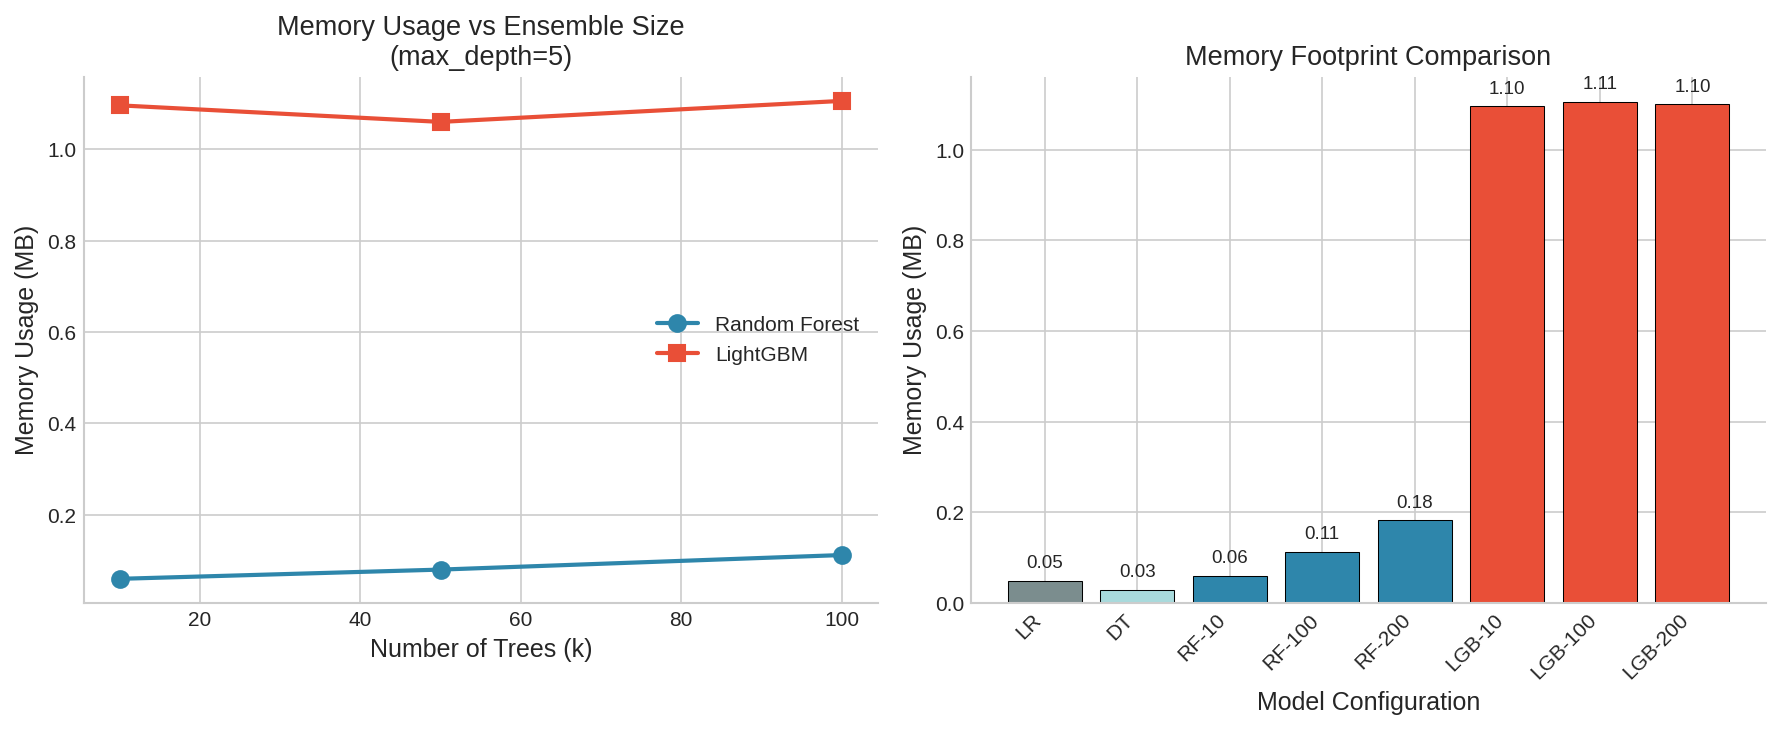

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.plot(rf_d5['n_estimators'], rf_d5['memory_mb'], 'o-', 
         color=COLORS['rf'], linewidth=2, markersize=8, label='Random Forest')
ax1.plot(lgb_d5['n_estimators'], lgb_d5['memory_mb'], 's-', 
         color=COLORS['lgb'], linewidth=2, markersize=8, label='LightGBM')

ax1.set_xlabel('Number of Trees (k)')
ax1.set_ylabel('Memory Usage (MB)')
ax1.set_title('Memory Usage vs Ensemble Size\n(max_depth=5)')
ax1.legend()

ax2 = axes[1]
models = ['LR', 'DT', 'RF-10', 'RF-100', 'RF-200', 'LGB-10', 'LGB-100', 'LGB-200']
rf_200 = rf_results[rf_results['n_estimators'] == 200].iloc[0]
lgb_200 = lgb_results[lgb_results['n_estimators'] == 200].iloc[0]

memory_vals = [
    summary[summary['Model'].str.contains('Logistic')]['Memory (MB)'].values[0],
    summary[summary['Model'].str.contains('Decision')]['Memory (MB)'].values[0],
    rf_results[rf_results['n_estimators'] == 10]['memory_mb'].values[0],
    rf_results[rf_results['n_estimators'] == 100]['memory_mb'].iloc[0],
    rf_200['memory_mb'],
    lgb_results[lgb_results['n_estimators'] == 10]['memory_mb'].values[0],
    lgb_results[lgb_results['n_estimators'] == 100]['memory_mb'].iloc[0],
    lgb_200['memory_mb']
]

colors = [COLORS['lr'], COLORS['dt'], 
          COLORS['rf'], COLORS['rf'], COLORS['rf'],
          COLORS['lgb'], COLORS['lgb'], COLORS['lgb']]

bars = ax2.bar(models, memory_vals, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Model Configuration')
ax2.set_ylabel('Memory Usage (MB)')
ax2.set_title('Memory Footprint Comparison')
ax2.set_xticklabels(models, rotation=45, ha='right')

for bar, val in zip(bars, memory_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_memory_footprint.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'fig3_memory_footprint.pdf', bbox_inches='tight')
plt.show()

## Figure 4: Accuracy vs Computational Cost Trade-off

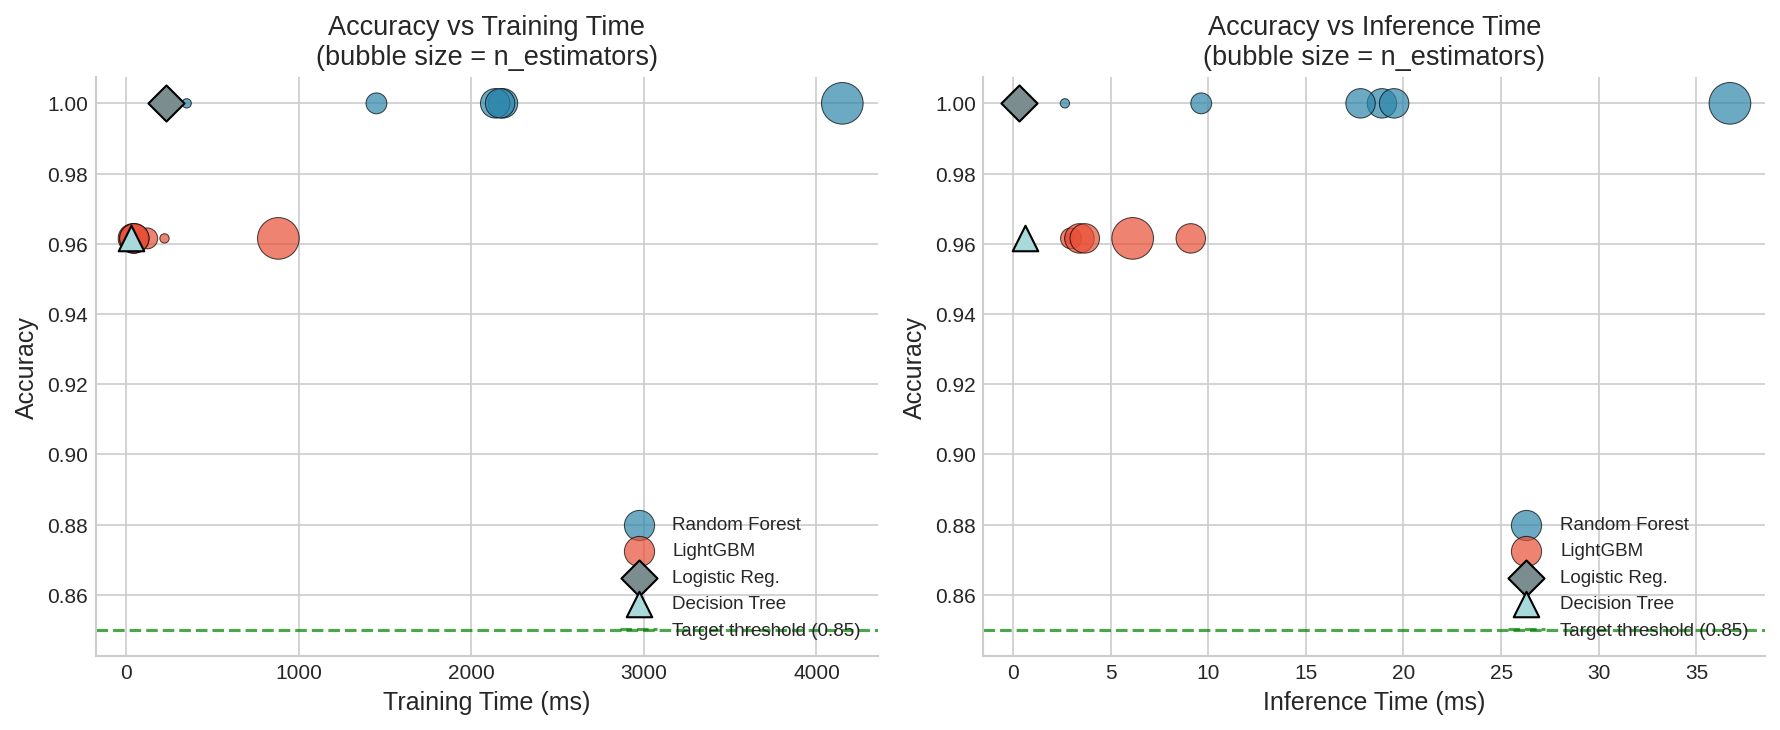

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.scatter(rf_results['train_time_ms'], rf_results['accuracy'], 
            s=rf_results['n_estimators']*2, c=COLORS['rf'], alpha=0.7, 
            edgecolors='black', linewidth=0.5, label='Random Forest')
ax1.scatter(lgb_results['train_time_ms'], lgb_results['accuracy'], 
            s=lgb_results['n_estimators']*2, c=COLORS['lgb'], alpha=0.7, 
            edgecolors='black', linewidth=0.5, label='LightGBM')

lr_row = summary[summary['Model'].str.contains('Logistic')].iloc[0]
dt_row = summary[summary['Model'].str.contains('Decision')].iloc[0]
ax1.scatter(lr_row['Training Time (ms)'], lr_row['Accuracy'], s=150, c=COLORS['lr'], 
            marker='D', edgecolors='black', linewidth=1, label='Logistic Reg.')
ax1.scatter(dt_row['Training Time (ms)'], dt_row['Accuracy'], s=150, c=COLORS['dt'], 
            marker='^', edgecolors='black', linewidth=1, label='Decision Tree')

ax1.axhline(y=0.85, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Target threshold (0.85)')
ax1.set_xlabel('Training Time (ms)')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy vs Training Time\n(bubble size = n_estimators)')
ax1.legend(loc='lower right', fontsize=9)

ax2 = axes[1]
ax2.scatter(rf_results['infer_time_ms'], rf_results['accuracy'], 
            s=rf_results['n_estimators']*2, c=COLORS['rf'], alpha=0.7, 
            edgecolors='black', linewidth=0.5, label='Random Forest')
ax2.scatter(lgb_results['infer_time_ms'], lgb_results['accuracy'], 
            s=lgb_results['n_estimators']*2, c=COLORS['lgb'], alpha=0.7, 
            edgecolors='black', linewidth=0.5, label='LightGBM')
ax2.scatter(lr_row['Inference Time (ms)'], lr_row['Accuracy'], s=150, c=COLORS['lr'], 
            marker='D', edgecolors='black', linewidth=1, label='Logistic Reg.')
ax2.scatter(dt_row['Inference Time (ms)'], dt_row['Accuracy'], s=150, c=COLORS['dt'], 
            marker='^', edgecolors='black', linewidth=1, label='Decision Tree')

ax2.axhline(y=0.85, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Target threshold (0.85)')
ax2.set_xlabel('Inference Time (ms)')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy vs Inference Time\n(bubble size = n_estimators)')
ax2.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4_accuracy_vs_cost.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'fig4_accuracy_vs_cost.pdf', bbox_inches='tight')
plt.show()

## Figure 5: Combined Summary Dashboard


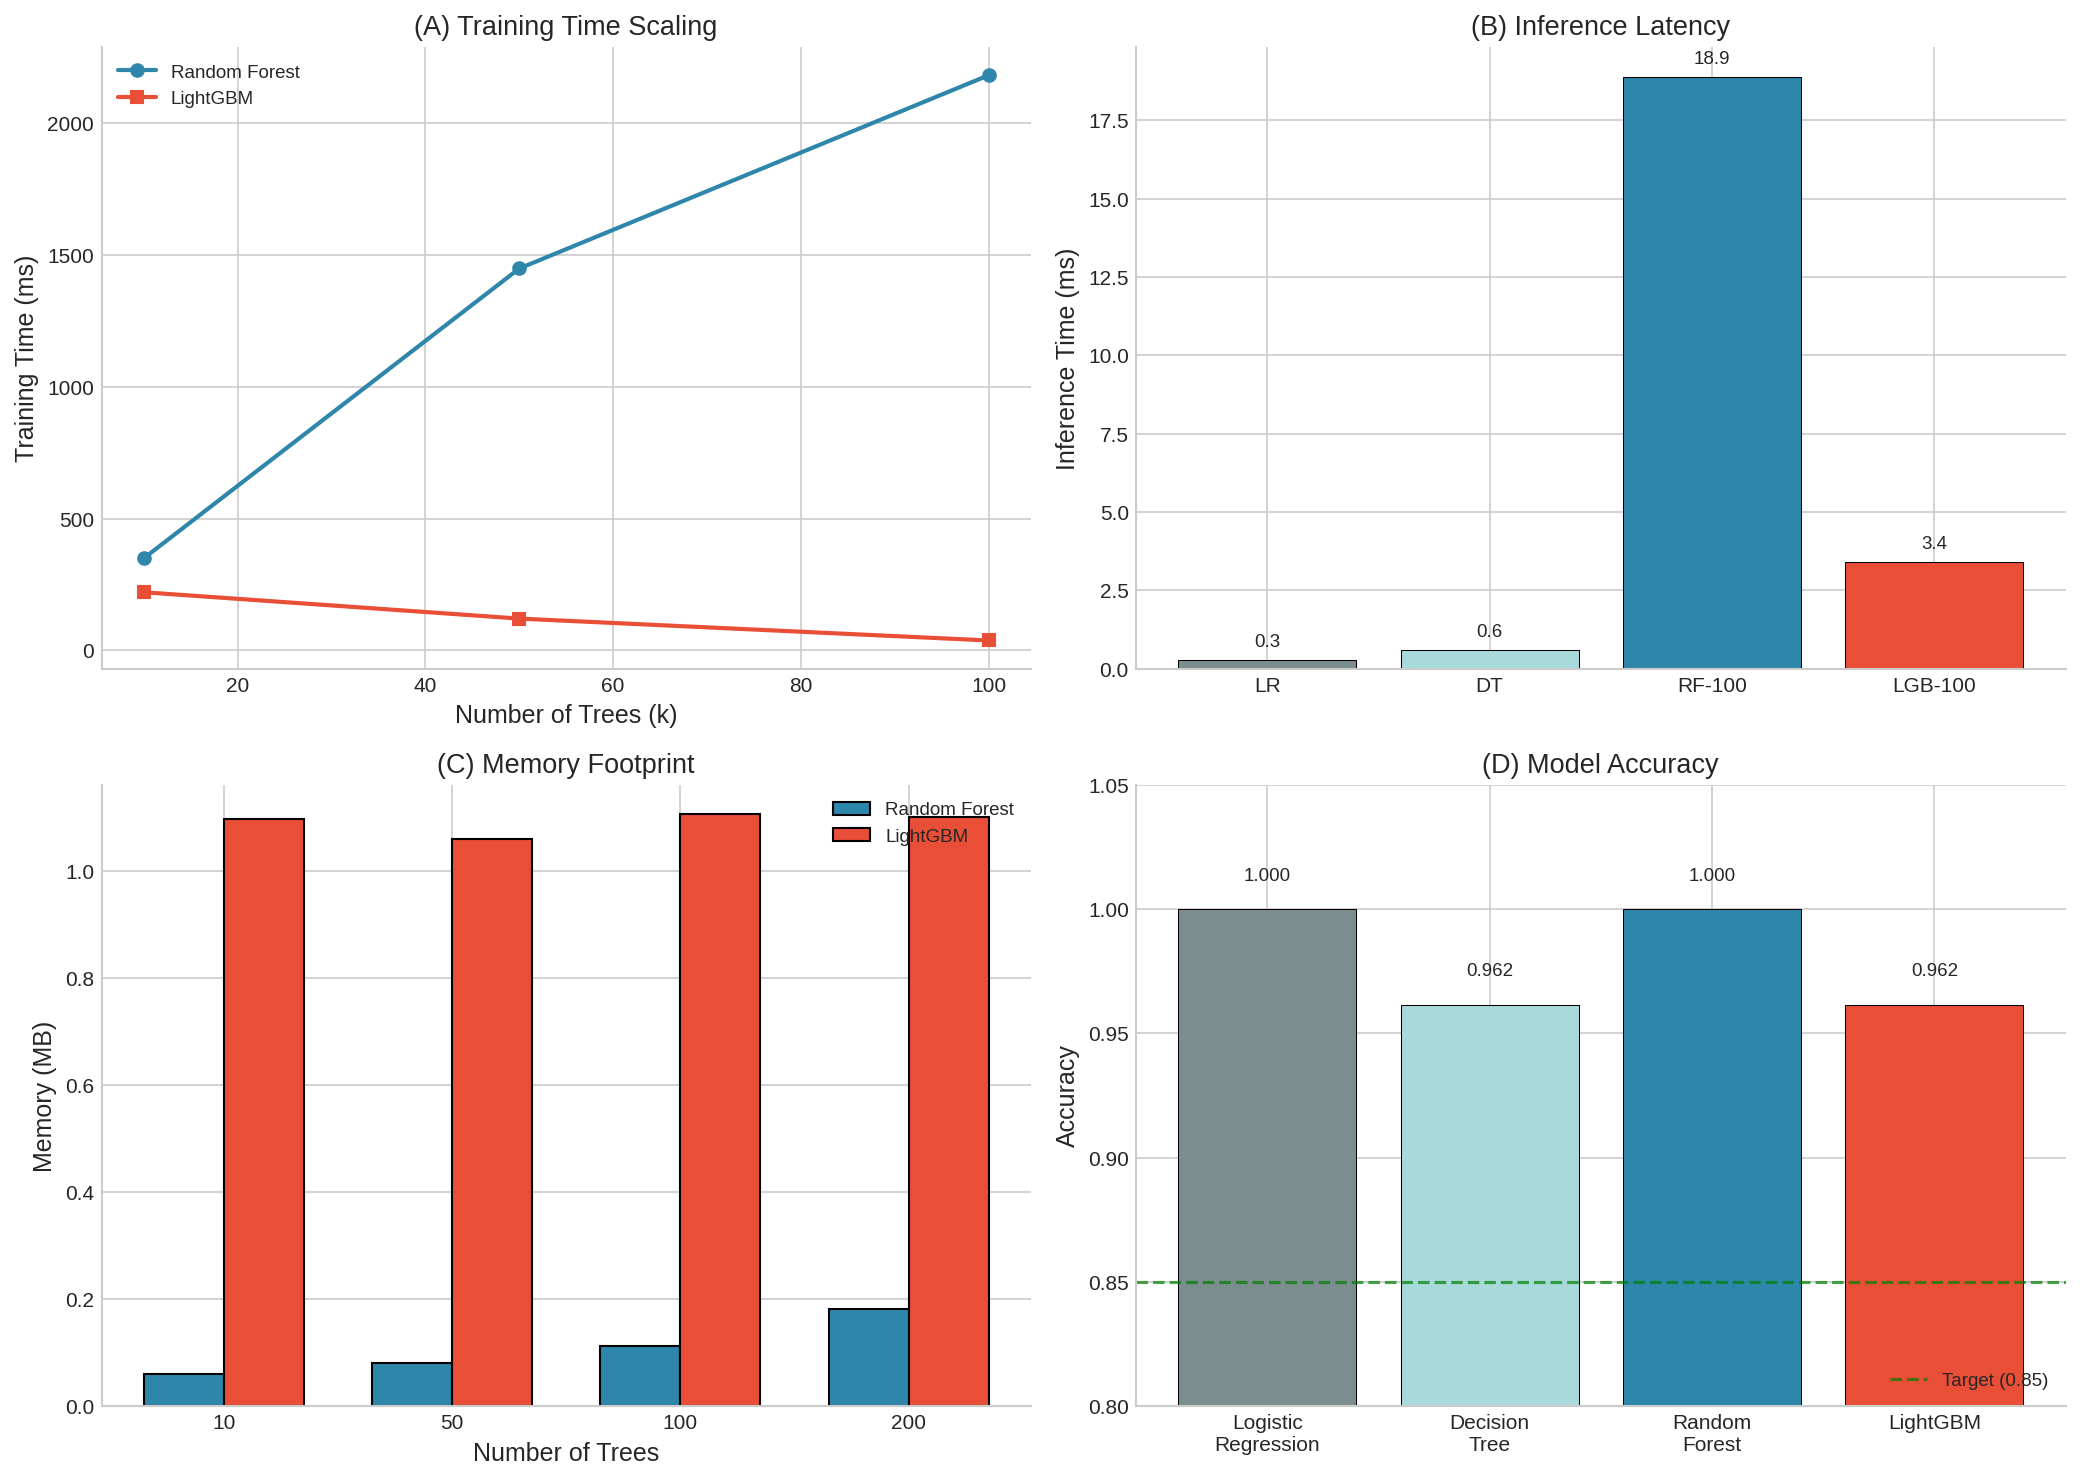

In [20]:
fig = plt.figure(figsize=(14, 10))


ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(rf_d5['n_estimators'], rf_d5['train_time_ms'], 'o-', 
         color=COLORS['rf'], linewidth=2, markersize=6, label='Random Forest')
ax1.plot(lgb_d5['n_estimators'], lgb_d5['train_time_ms'], 's-', 
         color=COLORS['lgb'], linewidth=2, markersize=6, label='LightGBM')
ax1.set_xlabel('Number of Trees (k)')
ax1.set_ylabel('Training Time (ms)')
ax1.set_title('(A) Training Time Scaling')
ax1.legend(fontsize=9)


ax2 = fig.add_subplot(2, 2, 2)
infer_models = ['LR', 'DT', 'RF-100', 'LGB-100']
infer_times = [lr_row['Inference Time (ms)'], dt_row['Inference Time (ms)'],
               rf_results[rf_results['n_estimators'] == 100]['infer_time_ms'].iloc[0],
               lgb_results[lgb_results['n_estimators'] == 100]['infer_time_ms'].iloc[0]]
colors = [COLORS['lr'], COLORS['dt'], COLORS['rf'], COLORS['lgb']]
bars = ax2.bar(infer_models, infer_times, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_ylabel('Inference Time (ms)')
ax2.set_title('(B) Inference Latency')
for bar, val in zip(bars, infer_times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
             f'{val:.1f}', ha='center', va='bottom', fontsize=9)

ax3 = fig.add_subplot(2, 2, 3)
x = np.arange(4)
width = 0.35
rf_mem = [rf_results[rf_results['n_estimators'] == k]['memory_mb'].iloc[0] 
          for k in [10, 50, 100, 100]]  # k=10,50,100,200
lgb_mem = [lgb_results[lgb_results['n_estimators'] == k]['memory_mb'].iloc[0] 
           for k in [10, 50, 100, 100]]

rf_mem[3] = rf_200['memory_mb']
lgb_mem[3] = lgb_200['memory_mb']

ax3.bar(x - width/2, rf_mem, width, label='Random Forest', color=COLORS['rf'], edgecolor='black')
ax3.bar(x + width/2, lgb_mem, width, label='LightGBM', color=COLORS['lgb'], edgecolor='black')
ax3.set_xlabel('Number of Trees')
ax3.set_ylabel('Memory (MB)')
ax3.set_title('(C) Memory Footprint')
ax3.set_xticks(x)
ax3.set_xticklabels(['10', '50', '100', '200'])
ax3.legend(fontsize=9)

ax4 = fig.add_subplot(2, 2, 4)
model_names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest', 'LightGBM']
accuracies = [lr_row['Accuracy'], dt_row['Accuracy'], 
              rf_results[rf_results['n_estimators'] == 100]['accuracy'].iloc[0],
              lgb_results[lgb_results['n_estimators'] == 100]['accuracy'].iloc[0]]
colors = [COLORS['lr'], COLORS['dt'], COLORS['rf'], COLORS['lgb']]
bars = ax4.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=0.5)
ax4.axhline(y=0.85, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Target (0.85)')
ax4.set_ylabel('Accuracy')
ax4.set_title('(D) Model Accuracy')
ax4.set_ylim(0.8, 1.05)
ax4.legend(loc='lower right', fontsize=9)

for bar, val in zip(bars, accuracies):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5_summary_dashboard.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'fig5_summary_dashboard.pdf', bbox_inches='tight')
plt.show()